In [1]:
# Cell 1
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import json, os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-04-11 08:56:17.061450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775897777.569710      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775897777.679394      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775897778.680144      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775897778.680186      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775897778.680189      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# Cell 2
train_df = pd.read_csv('/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv', header=None)
test_df  = pd.read_csv('/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv',  header=None)

print("Train shape:", train_df.shape)   # (87554, 188)
print("Test shape: ", test_df.shape)    # (21892, 188)

# Split features and labels
# First 187 columns = signal, last column = label
X_train_raw = train_df.iloc[:, :187].values.astype(np.float32)
y_train_raw = train_df.iloc[:, 187].values.astype(np.int32)

X_test  = test_df.iloc[:, :187].values.astype(np.float32)
y_test  = test_df.iloc[:, 187].values.astype(np.int32)

CLASS_NAMES = {
    0: 'Normal (N)',
    1: 'Supraventricular (S)',
    2: 'Ventricular (V)',
    3: 'Fusion (F)',
    4: 'Unknown (Q)'
}

# Check class distribution
print("\nClass distribution (train):")
unique, counts = np.unique(y_train_raw, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CLASS_NAMES[u]}: {c} ({100*c/len(y_train_raw):.1f}%)")

Train shape: (87554, 188)
Test shape:  (21892, 188)

Class distribution (train):
  Normal (N): 72471 (82.8%)
  Supraventricular (S): 2223 (2.5%)
  Ventricular (V): 5788 (6.6%)
  Fusion (F): 641 (0.7%)
  Unknown (Q): 6431 (7.3%)


In [3]:
# Cell 3
# WHY SMOTE: without it the model learns "always say Normal" 
# and gets 82% accuracy but misses ALL dangerous arrhythmias

smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_train_raw, y_train_raw)

print("After SMOTE:")
unique, counts = np.unique(y_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {CLASS_NAMES[u]}: {c}")
# All classes now equal ~72,471 samples

After SMOTE:
  Normal (N): 72471
  Supraventricular (S): 72471
  Ventricular (V): 72471
  Fusion (F): 72471
  Unknown (Q): 72471


In [4]:
# Cell 4
WINDOW_SIZE = 187
NUM_CLASSES = 5

# Reshape for Conv1D: (samples, timesteps, channels)
X_resampled = X_resampled.reshape(-1, WINDOW_SIZE, 1)
X_test      = X_test.reshape(-1, WINDOW_SIZE, 1)

# Validation split (10% of resampled train)
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled,
    test_size=0.1, random_state=42, stratify=y_resampled
)

# One-hot encode
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"X_train: {X_train.shape}")   # (~325k, 187, 1)
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")    # (21892, 187, 1)

# Save for faster re-runs
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/X_val.npy',   X_val)
np.save('/kaggle/working/X_test.npy',  X_test)
np.save('/kaggle/working/y_train.npy', y_train_cat)
np.save('/kaggle/working/y_val.npy',   y_val_cat)
np.save('/kaggle/working/y_test.npy',  y_test_cat)
print("Saved.")

X_train: (326119, 187, 1)
X_val:   (36236, 187, 1)
X_test:  (21892, 187, 1)
Saved.


In [5]:
# Cell 5
def residual_block(x, filters, kernel_size=3, dilation_rate=1, dropout_rate=0.2):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding='same',
                      dilation_rate=dilation_rate,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Conv1D(filters, kernel_size, padding='same',
                      dilation_rate=dilation_rate,
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    # Project shortcut if channel dimensions differ
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])   # skip connection
    x = layers.Activation('relu')(x)
    return x


def build_model(input_shape=(187, 1), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Stem
    x = layers.Conv1D(32, 7, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)           # 187 → 93

    # Stage 1 — 32 filters
    for _ in range(3):
        x = residual_block(x, 32, kernel_size=5)
    x = layers.MaxPooling1D(2)(x)           # 93 → 46

    # Stage 2 — 64 filters, dilated
    for dil in [1, 2, 1, 2]:
        x = residual_block(x, 64, kernel_size=5, dilation_rate=dil)
    x = layers.MaxPooling1D(2)(x)           # 46 → 23

    # Stage 3 — 128 filters, dilated
    for dil in [1, 2, 4, 1]:
        x = residual_block(x, 128, kernel_size=3, dilation_rate=dil)
    x = layers.MaxPooling1D(2)(x)           # 23 → 11

    # Stage 4 — 256 filters
    for _ in range(3):
        x = residual_block(x, 256, kernel_size=3)

    # Head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name='ECG_ResNet1D')


model = build_model()
model.summary()

I0000 00:00:1775897825.309657      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775897825.315387      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ECG_ResNet1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 187, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 187, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 32)    │      5,152 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 93, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 93, 32)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 93, 32)    │      5,152 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 32)    │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 93, 32)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 93, 32)    │      5,152 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 32)    │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 93, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 93, 32)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 93, 32)    │      5,152 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 32)    │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 1,796,613 (6.85 MB)

 Trainable params: 1,788,613 (6.82 MB)

 Non-trainable params: 8,000 (31.25 KB)

In [6]:
# Cell 6
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks = [
    ModelCheckpoint('/kaggle/working/best_model.h5',
                    monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


I0000 00:00:1775897848.409926      82 service.cc:152] XLA service 0x78cc1c01d180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775897848.409966      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775897848.409989      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775897852.260569      82 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/1274 ━━━━━━━━━━━━━━━━━━━━ 1:28 69ms/step - accuracy: 0.1914 - auc: 0.5149 - loss: 2.6037 - precision: 0.1654 - recall: 0.0801   

I0000 00:00:1775897874.396202      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1274/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8187 - auc: 0.9566 - loss: 0.8116 - precision: 0.8631 - recall: 0.7768
Epoch 1: val_auc improved from -inf to 0.99475, saving model to /kaggle/working/best_model.h5


...

1274/1274 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.9917 - auc: 0.9996 - loss: 0.0791 - precision: 0.9919 - recall: 0.9914 - val_accuracy: 0.9954 - val_auc: 0.9998 - val_loss: 0.0654 - val_precision: 0.9955 - val_recall: 0.9952 - learning_rate: 0.0010
Epoch 15/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9920 - auc: 0.9996 - loss: 0.0771 - precision: 0.9923 - recall: 0.9919
Epoch 15: val_auc did not improve from 0.99975
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.9920 - auc: 0.9996 - loss: 0.0771 - precision: 0.9923 - recall: 0.9918 - val_accuracy: 0.9943 - val_auc: 0.9997 - val_loss: 0.0673 - val_precision: 0.9945 - val_recall: 0.9941 - learning_rate: 0.0010
Epoch 16/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9929 - auc: 0.9996 - loss: 0.0722 - precision: 0.9931 - recall: 0.9927
Epoch 16: val_auc did not improve from 0.99975
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9929 - auc: 0.9996 - loss: 0.0722 - precision

1274/1274 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.9928 - auc: 0.9997 - loss: 0.0684 - precision: 0.9930 - recall: 0.9926 - val_accuracy: 0.9958 - val_auc: 0.9998 - val_loss: 0.0572 - val_precision: 0.9959 - val_recall: 0.9957 - learning_rate: 0.0010
Epoch 19/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9931 - auc: 0.9997 - loss: 0.0664 - precision: 0.9933 - recall: 0.9929
Epoch 19: val_auc improved from 0.99979 to 0.99984, saving model to /kaggle/working/best_model.h5


1274/1274 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.9931 - auc: 0.9997 - loss: 0.0664 - precision: 0.9933 - recall: 0.9929 - val_accuracy: 0.9961 - val_auc: 0.9998 - val_loss: 0.0574 - val_precision: 0.9964 - val_recall: 0.9960 - learning_rate: 0.0010
Epoch 20/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9933 - auc: 0.9997 - loss: 0.0650 - precision: 0.9934 - recall: 0.9930
Epoch 20: val_auc did not improve from 0.99984
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9933 - auc: 0.9997 - loss: 0.0650 - precision: 0.9934 - recall: 0.9930 - val_accuracy: 0.9951 - val_auc: 0.9998 - val_loss: 0.0576 - val_precision: 0.9952 - val_recall: 0.9949 - learning_rate: 0.0010
Epoch 21/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9930 - auc: 0.9997 - loss: 0.0630 - precision: 0.9932 - recall: 0.9928
Epoch 21: val_auc did not improve from 0.99984
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9930 - auc: 0.9997 - loss: 0.0630 - precision

1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9937 - auc: 0.9996 - loss: 0.0614 - precision: 0.9939 - recall: 0.9935 - val_accuracy: 0.9961 - val_auc: 0.9999 - val_loss: 0.0527 - val_precision: 0.9962 - val_recall: 0.9961 - learning_rate: 0.0010
Epoch 23/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9938 - auc: 0.9997 - loss: 0.0586 - precision: 0.9940 - recall: 0.9936
Epoch 23: val_auc did not improve from 0.99986
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.9938 - auc: 0.9997 - loss: 0.0586 - precision: 0.9940 - recall: 0.9936 - val_accuracy: 0.9953 - val_auc: 0.9996 - val_loss: 0.0561 - val_precision: 0.9953 - val_recall: 0.9951 - learning_rate: 0.0010
Epoch 24/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9940 - auc: 0.9997 - loss: 0.0573 - precision: 0.9942 - recall: 0.9939
Epoch 24: val_auc did not improve from 0.99986
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.9940 - auc: 0.9997 - loss: 0.0573 - precision

1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.9947 - auc: 0.9997 - loss: 0.0494 - precision: 0.9948 - recall: 0.9946 - val_accuracy: 0.9972 - val_auc: 0.9999 - val_loss: 0.0433 - val_precision: 0.9972 - val_recall: 0.9972 - learning_rate: 0.0010
Epoch 32/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9950 - auc: 0.9998 - loss: 0.0482 - precision: 0.9952 - recall: 0.9949
Epoch 32: val_auc did not improve from 0.99990
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.9950 - auc: 0.9998 - loss: 0.0482 - precision: 0.9952 - recall: 0.9949 - val_accuracy: 0.9951 - val_auc: 0.9996 - val_loss: 0.0460 - val_precision: 0.9951 - val_recall: 0.9949 - learning_rate: 0.0010
Epoch 33/100
1273/1274 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9952 - auc: 0.9998 - loss: 0.0462 - precision: 0.9953 - recall: 0.9951
Epoch 33: val_auc did not improve from 0.99990
1274/1274 ━━━━━━━━━━━━━━━━━━━━ 49s 38ms/step - accuracy: 0.9952 - auc: 0.9998 - loss: 0.0462 - precision

  loss: 0.1025
  compile_metrics: 0.9861
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step

                       precision    recall  f1-score   support

          Normal (N)       0.99      0.99      0.99     18118
Supraventricular (S)       0.87      0.85      0.86       556
     Ventricular (V)       0.97      0.96      0.96      1448
          Fusion (F)       0.75      0.85      0.79       162
         Unknown (Q)       0.99      0.99      0.99      1608

            accuracy                           0.99     21892
           macro avg       0.91      0.93      0.92     21892
        weighted avg       0.99      0.99      0.99     21892



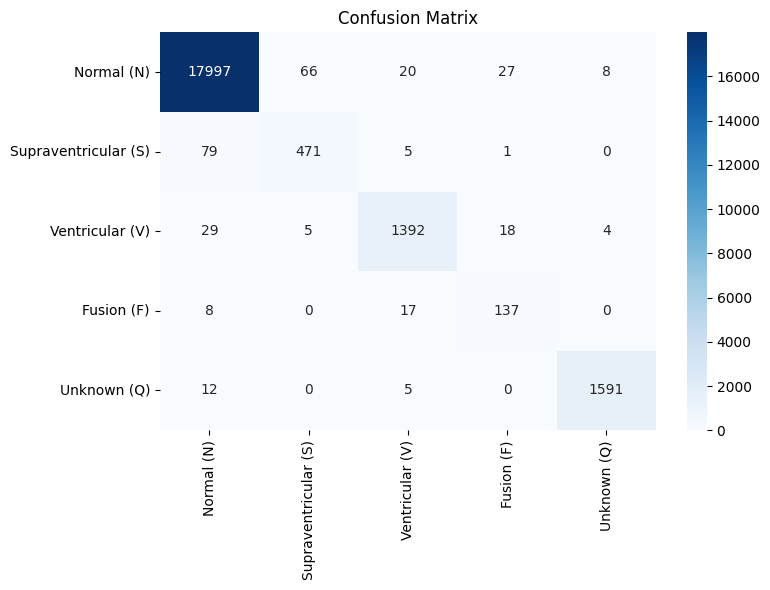

In [7]:
# Cell 7
from sklearn.metrics import classification_report, confusion_matrix

results = model.evaluate(X_test, y_test_cat, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"  {name}: {val:.4f}")

y_pred = np.argmax(model.predict(X_test, batch_size=512), axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n", classification_report(y_true, y_pred,
      target_names=list(CLASS_NAMES.values())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES.values(),
            yticklabels=CLASS_NAMES.values())
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [8]:
# Cell 8
model.save('/kaggle/working/ecg_arrhythmia_model.h5')

metadata = {
    "window_size": 187,
    "num_classes": 5,
    "class_names": {str(k): v for k, v in CLASS_NAMES.items()},
    "input_shape": [187, 1],
    "already_normalized": True,   # signals in this dataset are pre-normalized [0,1]
    "model_version": "1.0.0"
}
with open('/kaggle/working/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Done. Download these two files from the Output tab:")
print("  → ecg_arrhythmia_model.h5")
print("  → model_metadata.json")

Done. Download these two files from the Output tab:
  → ecg_arrhythmia_model.h5
  → model_metadata.json
